## <center> <b> <span style="color:blue;">Deep Learning with CNN for Clothing Classification using Fashion-MNIST dataset</span> </b></center>

### 1) Design a CNN Model Using PyTorch

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as FMNIST

# Define CNN Model
class CNNFashion(nn.Module):
    def __init__(self, num_classes=10):
        super(CNNFashion, self).__init__()
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, padding=1)  # Conv Layer 1
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)  # Conv Layer 2
        self.pool = nn.MaxPool2d(2, 2)  # Max Pooling
        self.fc1 = nn.Linear(64 * 7 * 7, 128)  # Fully Connected Layer 1
        self.fc2 = nn.Linear(128, num_classes)  # Fully Connected Layer 2 (10 classes)
        
    
    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))  # Apply ReLU activation
        x = self.pool(F.relu(self.conv2(x)))  
        x = x.view(x.size(0), -1)  # Flatten tensor
        x = F.relu(self.fc1(x))
        x = self.fc2(x)  # Output logits
        return x

This cell above is a Convolutional Neural Network (CNN) designed for Fashion-MNIST classification using PyTorch.
### 1) Model Initialization
The model consists of:

- Convolutional Layers

    - `conv1`: 1 input channel (grayscale images) → 32 output channels
    - `conv2`: 32 input channels → 64 output channels

- Pooling Layer

    - `MaxPool2d(2,2)`: Reduces spatial dimensions by half (Downsampling)

- Fully Connected Layers

     - `fc1`: Flattens image features and connects them to 128 neurons
     - `fc2`: Final layer with 10 output classes (for classification)

### 2)Forward Pass (forward method)

- First Convolution + ReLU + MaxPooling

    - `conv1` extracts 32 feature maps → ReLU applies activation → MaxPooling (2x2) downsamples the feature maps

- Second Convolution + `ReLU` + `MaxPooling`

    - `conv2` extracts 64 feature maps → ReLU applies activation → MaxPooling (2x2) downsamples the feature maps

- Flattening the Output

    - Converts 3D feature maps into a 1D vector

- Fully Connected Layers

    - Passes through `fc1` with `ReLU` activation
    - Final `fc2` layer outputs logits for 10 classes

## 2) Load the Dataset & Train the CNN Model

In [4]:
import pandas as pd
import numpy as np
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image

# Custom dataset class for Fashion-MNIST CSV files
class FashionMNISTDataset(Dataset):
    def __init__(self, csv_file, transform=None):
        self.data = pd.read_csv(csv_file)
        self.images = self.data.iloc[:, 1:].values.reshape(-1, 28, 28)  # Reshape into images
        self.labels = self.data.iloc[:, 0].values  # Labels are in the first column
        self.transform = transform

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        image = self.images[idx].astype(np.uint8)  # Convert to uint8
        image = Image.fromarray(image)  # Convert to PIL Image

        if self.transform:
            image = self.transform(image)  # Apply transformations

        label = torch.tensor(self.labels[idx], dtype=torch.long)
        return image, label

# Define transformations (No augmentation yet)
transform = transforms.Compose([
    transforms.ToTensor(),  
    transforms.Normalize((0.5,), (0.5,))  # Normalize images
])

train_path = "/home/leonard/Documents/Leonard/mnist_fashion_train.csv"
test_path  = "/home/leonard/Documents/Leonard/mnist_fashion_test.csv"

# Load datasets
train_dataset = FashionMNISTDataset(train_path, transform=transform)
test_dataset = FashionMNISTDataset(test_path, transform=transform)

# DataLoader
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)


In [5]:
def output_label(label):
    output_mapping = {
                 0: "T-shirt/Top",
                 1: "Trouser",
                 2: "Pullover",
                 3: "Dress",
                 4: "Coat", 
                 5: "Sandal", 
                 6: "Shirt",
                 7: "Sneaker",
                 8: "Bag",
                 9: "Ankle Boot"
                 }
    input = (label.item() if type(label) == torch.Tensor else label)
    return output_mapping[input]

In [6]:
demo_loader = torch.utils.data.DataLoader(train_dataset, batch_size=10)

batch = next(iter(demo_loader))
images, labels = batch
print(type(images), type(labels))
print(images.shape, labels.shape)

<class 'torch.Tensor'> <class 'torch.Tensor'>
torch.Size([10, 1, 28, 28]) torch.Size([10])


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..1.0].


labels:  Ankle Boot, T-shirt/Top, T-shirt/Top, Dress, T-shirt/Top, Pullover, Sneaker, Pullover, Sandal, Sandal, 

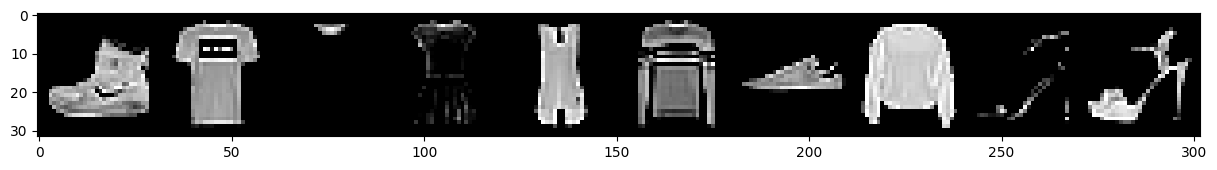

In [7]:
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt

grid = torchvision.utils.make_grid(images, nrow=10)

plt.figure(figsize=(15, 20))
plt.imshow(np.transpose(grid, (1, 2, 0)))
print("labels: ", end=" ")
for i, label in enumerate(labels):
    print(output_label(label), end=", ")

## Train the CNN Model

In [8]:
import torch.optim as optim

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Initialize model, loss function, and optimizer
model = CNNFashion().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Training function
def train_model(model, train_loader, criterion, optimizer, num_epochs=30):
    model.train()
    for epoch in range(num_epochs):
        running_loss = 0.0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()

        print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {running_loss/len(train_loader):.4f}")

# Train the model
train_model(model, train_loader, criterion, optimizer)


Epoch [1/30], Loss: 0.4313
Epoch [2/30], Loss: 0.2814
Epoch [3/30], Loss: 0.2375
Epoch [4/30], Loss: 0.2034
Epoch [5/30], Loss: 0.1777
Epoch [6/30], Loss: 0.1577
Epoch [7/30], Loss: 0.1381
Epoch [8/30], Loss: 0.1173
Epoch [9/30], Loss: 0.1021
Epoch [10/30], Loss: 0.0860
Epoch [11/30], Loss: 0.0719
Epoch [12/30], Loss: 0.0631
Epoch [13/30], Loss: 0.0525
Epoch [14/30], Loss: 0.0468
Epoch [15/30], Loss: 0.0414
Epoch [16/30], Loss: 0.0354
Epoch [17/30], Loss: 0.0301
Epoch [18/30], Loss: 0.0299
Epoch [19/30], Loss: 0.0240
Epoch [20/30], Loss: 0.0261
Epoch [21/30], Loss: 0.0192
Epoch [22/30], Loss: 0.0238
Epoch [23/30], Loss: 0.0168
Epoch [24/30], Loss: 0.0231
Epoch [25/30], Loss: 0.0139
Epoch [26/30], Loss: 0.0160
Epoch [27/30], Loss: 0.0178
Epoch [28/30], Loss: 0.0164
Epoch [29/30], Loss: 0.0190
Epoch [30/30], Loss: 0.0119


## 2) Apply Data Augmentation
These transformations introduce variations in the dataset to improve the model’s generalization and prevent overfitting:

- `RandomRotation(5)` → Slightly rotates images by ±5 degrees to make the model invariant to minor orientation changes.
- `RandomHorizontalFlip(p=0.8)` → Flips images left-right with an $80%$ probability, helping the model recognize mirrored versions of the same class.
- `RandomAffine(degrees=0, translate=(0.05, 0.05))` → Slightly shifts images by $5%$ horizontally and vertically, making the model robust to small positional changes.
- `ToTensor()` → Converts images to PyTorch tensors for training.
- `Normalize((0.5,)`, (0.5,)) → Normalizes pixel values to $[-1, 1]$, stabilizing learning and improving convergence.

In [11]:
# Data augmentation transformations
# Improved Data Augmentation
transform_aug = transforms.Compose([
    transforms.RandomRotation(5),  # Rotate only slightly
    transforms.RandomHorizontalFlip(p=0.8),  # Flip images left-right
    transforms.RandomAffine(degrees=0, translate=(0.05, 0.05)),  # Reduce shift
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

# Load dataset with augmentation
train_dataset_aug = FashionMNISTDataset(train_path, transform=transform_aug)
train_loader_aug = DataLoader(train_dataset_aug, batch_size=64, shuffle=True)

# Train new model with augmentation
print("\nTraining WITH Data Augmentation...")
model_aug = CNNFashion().to(device)
optimizer_aug = optim.Adam(model_aug.parameters(), lr=0.001)

train_model(model_aug, train_loader_aug, criterion, optimizer_aug)



Training WITH Data Augmentation...
Epoch [1/30], Loss: 0.5251
Epoch [2/30], Loss: 0.3491
Epoch [3/30], Loss: 0.3014
Epoch [4/30], Loss: 0.2708
Epoch [5/30], Loss: 0.2545
Epoch [6/30], Loss: 0.2381
Epoch [7/30], Loss: 0.2272
Epoch [8/30], Loss: 0.2174
Epoch [9/30], Loss: 0.2074
Epoch [10/30], Loss: 0.2009
Epoch [11/30], Loss: 0.1961
Epoch [12/30], Loss: 0.1887
Epoch [13/30], Loss: 0.1832
Epoch [14/30], Loss: 0.1775
Epoch [15/30], Loss: 0.1721
Epoch [16/30], Loss: 0.1673
Epoch [17/30], Loss: 0.1653
Epoch [18/30], Loss: 0.1592
Epoch [19/30], Loss: 0.1584
Epoch [20/30], Loss: 0.1551
Epoch [21/30], Loss: 0.1480
Epoch [22/30], Loss: 0.1484
Epoch [23/30], Loss: 0.1451
Epoch [24/30], Loss: 0.1425
Epoch [25/30], Loss: 0.1391
Epoch [26/30], Loss: 0.1389
Epoch [27/30], Loss: 0.1358
Epoch [28/30], Loss: 0.1347
Epoch [29/30], Loss: 0.1331
Epoch [30/30], Loss: 0.1281


## 4) Validate and Compare Performance
Evaluate the model by the accuracy

In [12]:
def evaluate_model(test_loader, model):
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    accuracy = 100 * correct / total
    return accuracy

# Test accuracy without augmentation
print("#"*40)
accuracy_no_aug = evaluate_model(test_loader, model)
print(f"\nTest Accuracy WITHOUT Augmentation: {accuracy_no_aug:.2f}%")

# Test accuracy with augmentation
accuracy_with_aug = evaluate_model(test_loader, model_aug)
print(f"\nTest Accuracy WITH Augmentation: {accuracy_with_aug:.2f}%")
print("\n")
print("#"*40)

########################################

Test Accuracy WITHOUT Augmentation: 91.75%

Test Accuracy WITH Augmentation: 92.39%


########################################


>This result suggest that augmentation  have a big effects on the model.

## Looking the Accuracy in each class for each model


## i) Model without augmentation

In [13]:
import pandas as pd

class_correct = [0. for _ in range(10)]
class_misclassified = [0. for _ in range(10)] 
total_correct = [0. for _ in range(10)]

# Disable gradient calculation for testing
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        
        # No need to wrap images in Variable
        outputs = model(images)
        predicted = torch.max(outputs, 1)[1]  # Get the predicted classes
        c = (predicted == labels).squeeze()  # Check which predictions are correct
        
        for i in range(len(images)):  # Use the batch size dynamically
            label = labels[i]  # Get the true label
            class_correct[label] += c[i].item()  # Increment correct count for the class
            total_correct[label] += 1  # Increment total count for the class
            if not c[i].item():  # If prediction is incorrect
                class_misclassified[label] += 1  # Increment misclassified count

# Prepare data for DataFrame
accuracy_data = {
    "Class": [output_label(i) for i in range(10)],
    "Correct": class_correct,
    "Misclassified": class_misclassified,
    "Total": total_correct,
    "Accuracy (%)": [
        (class_correct[i] * 100 / total_correct[i]) if total_correct[i] > 0 else 0
        for i in range(10)
    ]
}

# Create DataFrame
accuracy_df = pd.DataFrame(accuracy_data)

# Display the DataFrame
accuracy_df

,Class,Correct,Misclassified,Total,Accuracy (%)
0,T-shirt/Top,864.0,136.0,1000.0,86.4
1,Trouser,983.0,17.0,1000.0,98.3
2,Pullover,873.0,127.0,1000.0,87.3
3,Dress,917.0,83.0,1000.0,91.7
4,Coat,864.0,136.0,1000.0,86.4
5,Sandal,982.0,18.0,1000.0,98.2
6,Shirt,753.0,247.0,1000.0,75.3
7,Sneaker,979.0,21.0,1000.0,97.9
8,Bag,985.0,15.0,1000.0,98.5
9,Ankle Boot,975.0,25.0,1000.0,97.5


# ii) Model with augmentation

In [14]:
import pandas as pd

class_correct = [0. for _ in range(10)]
total_correct = [0. for _ in range(10)]

# Disable gradient calculation for testing
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        
        # No need to wrap images in Variable
        outputs = model_aug(images)
        predicted = torch.max(outputs, 1)[1]  # Get the predicted classes
        c = (predicted == labels).squeeze()  # Check which predictions are correct
        
        for i in range(len(images)):  # Use the batch size dynamically
            label = labels[i]  # Get the true label
            class_correct[label] += c[i].item()  # Increment correct count for the class
            total_correct[label] += 1  # Increment total count for the class

# Prepare data for DataFrame
accuracy_data = {
    "Class": [output_label(i) for i in range(10)],
    "Correct": class_correct,
    "Total": total_correct,
    "Accuracy (%)": [
        (class_correct[i] * 100 / total_correct[i]) if total_correct[i] > 0 else 0
        for i in range(10)
    ]
}

# Create DataFrame
accuracy_df = pd.DataFrame(accuracy_data)

# Display the DataFrame
accuracy_df

,Class,Correct,Total,Accuracy (%)
0,T-shirt/Top,863.0,1000.0,86.3
1,Trouser,988.0,1000.0,98.8
2,Pullover,895.0,1000.0,89.5
3,Dress,913.0,1000.0,91.3
4,Coat,863.0,1000.0,86.3
5,Sandal,979.0,1000.0,97.9
6,Shirt,822.0,1000.0,82.2
7,Sneaker,963.0,1000.0,96.3
8,Bag,986.0,1000.0,98.6
9,Ankle Boot,967.0,1000.0,96.7
